In [1]:
!python --version
!pip show torch
!pip show torchvision
!pip show fastai

Python 3.11.13
Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, stable-baselines3, timm, torchaudio, torchdata, torchmetrics, torchvision
Name: torchvision
Version: 0.21.0+cu124
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: 

In [2]:
!pip install -Uqq fastai icrawler --use-deprecated=legacy-resolver

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.3/235.3 kB 5.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━

In [3]:
!python --version
!pip show torch
!pip show torchvision
!pip show fastai

Python 3.11.13
Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, stable-baselines3, timm, torchaudio, torchdata, torchmetrics, torchvision
Name: torchvision
Version: 0.21.0+cu124
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: 

# STEP 1: GATHER IMAGES FOR DATASET

In [4]:
from icrawler.builtin import GoogleImageCrawler
from pathlib import Path
import shutil

# Define the parent directory for our dataset
DATASET_PATH = Path('./dataset')

# Define the classes and their corresponding search queries
# Using multiple specific queries per class yields better results
CLASSES = {
    "birds": ['photo of a bird flying', 'bird in flight photography', 'eagle flying high resolution',
    'pigeon in flight against sky', 'seagull flying over water'],
    "planes": ['airplane flying in the sky photo', 'commercial airplane in flight', 'jet fighter in flight',
    'airplane taking off from runway', 'view of airplane from the ground'],
    "superman": ['superman flying pose', 'superman flying in the sky', 'christopher reeve superman flying',
    'henry cavill superman flying', 'superman comic book flying']
}

# Loop through each class and its queries to download images
for class_name, queries in CLASSES.items():
    class_path = DATASET_PATH / class_name
    class_path.mkdir(parents=True, exist_ok=True)
    print(f"\nDownloading images for: {class_name}")

    google_crawler = GoogleImageCrawler(storage={'root_dir': str(class_path)})
    
    # We will download 150 images per query.
    # You can increase this number for a more robust dataset.
    for query in queries:
        try:
            print(f"  -> Crawling for query: '{query}'")
            google_crawler.crawl(keyword=query, max_num=150)
        except Exception as e:
            print(f"  -> Could not complete query '{query}'. Error: {e}")

print("\nImage gathering complete.")





  -> Crawling for query: 'photo of a bird flying'


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
TypeError: 'NoneType' object is not iterable


  -> Crawling for query: 'bird in flight photography'


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
TypeError: 'NoneType' object is not iterable


  -> Crawling for query: 'eagle flying high resolution'


...

  -> Crawling for query: 'henry cavill superman flying'


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
TypeError: 'NoneType' object is not iterable


  -> Crawling for query: 'superman comic book flying'


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
TypeError: 'NoneType' object is not iterable



Image gathering complete.


# STEP 1.1: AUTOMATED DATA CLEANING (PART 1)

In [5]:
# Before training, we MUST remove corrupt files that can't be opened.
print("\n--- PRE-TRAINING: VERIFYING IMAGES ---")
from fastai.vision.all import *

fns = get_image_files(DATASET_PATH)
print(f"Found {len(fns)} total images.")

failed = verify_images(fns)
if failed:
    print(f"Found {len(failed)} corrupt images. Deleting them now.")
    failed.map(Path.unlink)
else:
    print("No corrupt images found.")


--- PRE-TRAINING: VERIFYING IMAGES ---
Found 303 total images.
Found 1 corrupt images. Deleting them now.


# STEP 1.2: SETUP DATABLOCK

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


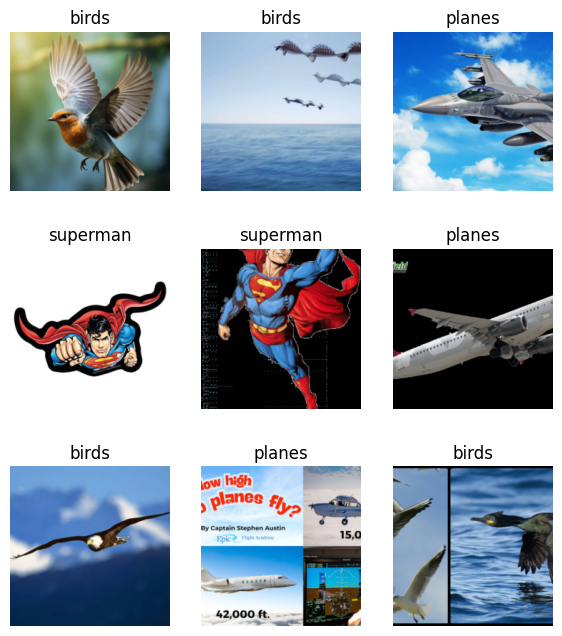

In [6]:
# Set up the DataBlock. This tells fastai how our data is structured.
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),    # Input is an image, output is a category
    get_items=get_image_files,             # How to find the images
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # Split 20% for validation
    get_y=parent_label,                    # The label is the name of the parent folder
    item_tfms=Resize(224)                  # Resize all images to 224x224 before batching
).dataloaders(DATASET_PATH, bs=32)

dls.show_batch(max_n=9, figsize=(7,8))

# STEP 2: TRAIN MODEL (FIRST PASS)

In [7]:
# Create the learner object
# resnet34 is a great starting architecture: fast and effective
learn = vision_learner(dls, resnet34, metrics=error_rate)

# Train the model. fine_tune is the recommended way to train transfer learning models.
# We'll train for 4 epochs as a baseline.
learn.fine_tune(4)

print("\nInitial model training complete.")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 176MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,1.468763,0.060393,0.000000,00:09


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,0.305282,0.021486,0.000000,00:08
1,0.207149,0.016030,0.000000,00:08
2,0.162722,0.009329,0.000000,00:09
3,0.121458,0.011662,0.000000,00:08


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in by


Initial model training complete.


# STEP 2.1: SHOW RESULTS

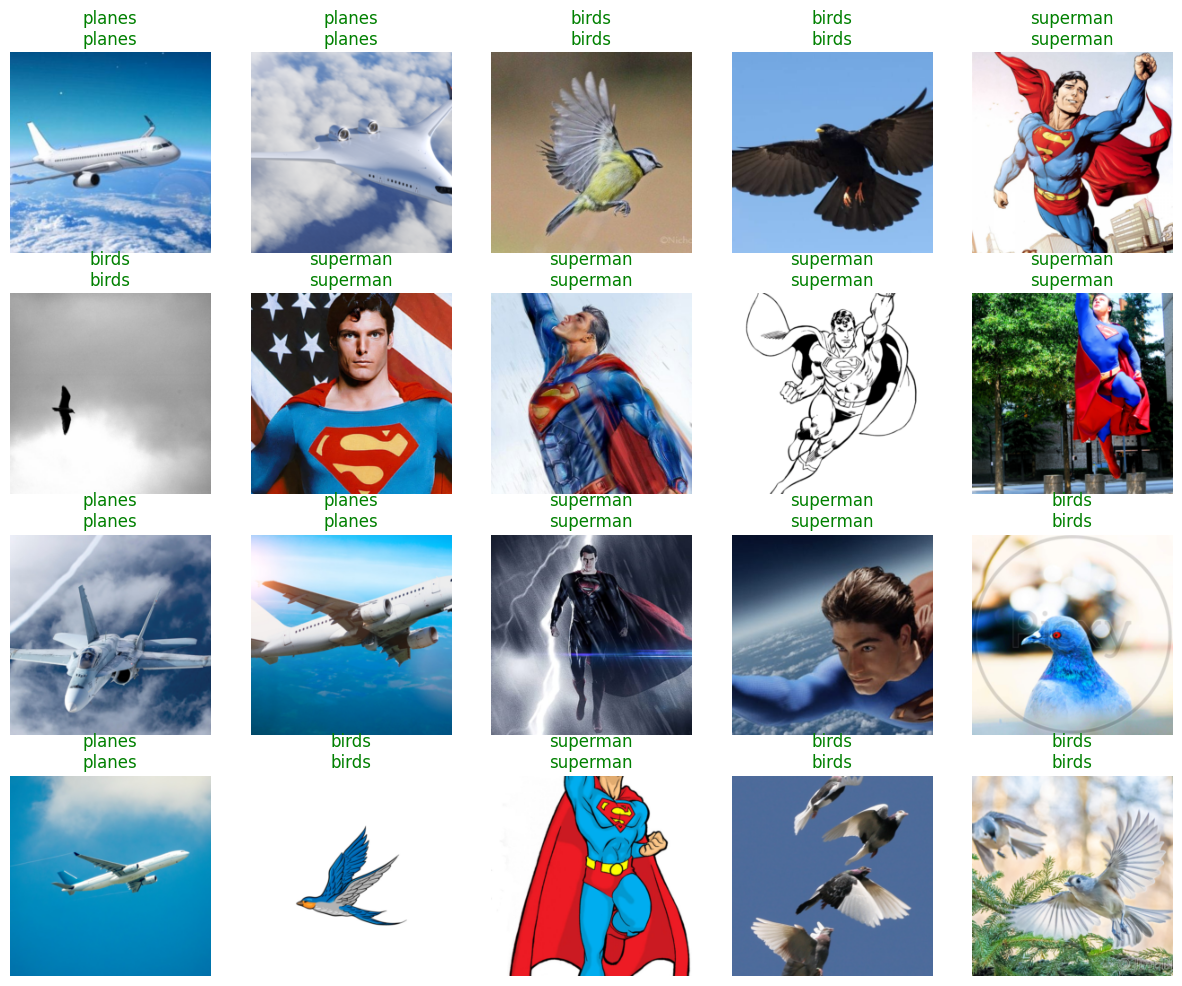

In [8]:
# Show partial results
learn.show_results(max_n=20)

# STEP 3: MANUALLY CLEAN DATA

In [9]:
print("\n--- STEP 3: INTERACTIVE DATA CLEANING ---")
print("--> The 'ImageClassifierCleaner' widget will now appear.")
print("--> Go through the images and select the correct category or mark them for deletion.")
print("--> IMPORTANT: This step is manual. The code will pause here until you are done.")

from fastai.vision.widgets import *

# Launch the interactive cleaner widget
cleaner = ImageClassifierCleaner(learn)
cleaner # The 'display()' command ensures the widget renders properly in Kaggle


--- STEP 3: INTERACTIVE DATA CLEANING ---
--> The 'ImageClassifierCleaner' widget will now appear.
--> Go through the images and select the correct category or mark them for deletion.
--> IMPORTANT: This step is manual. The code will pause here until you are done.


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [10]:
# After you have finished using the widget, the 'cleaner' object holds your changes.
# The following code will apply them to your dataset on disk.

# Delete images marked for deletion
for idx in cleaner.delete():
    print(f"Deleting: {cleaner.fns[idx]}")
    cleaner.fns[idx].unlink()

# Move images that were relabeled
for idx, cat in cleaner.change():
    print(f"Moving: {cleaner.fns[idx]} to category {cat}")
    dest = DATASET_PATH/cat
    dest.mkdir(exist_ok=True)
    shutil.move(str(cleaner.fns[idx]), dest)

print("\nData cleaning is complete. Your changes have been saved to the dataset.")


Data cleaning is complete. Your changes have been saved to the dataset.


# STEP 4: TRAIN MODEL

In [11]:
# We need to create a NEW DataLoaders object.
# This ensures it reads our cleaned and reorganized dataset.
dls_clean = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(224)
).dataloaders(DATASET_PATH, bs=32)

# Create a new learner with the clean DataLoaders
learn_clean = vision_learner(dls_clean, resnet34, metrics=error_rate)

# Train again for the same duration to see the improvement
learn_clean.fine_tune(4)

print("\nRetraining on cleaned data is complete.")


epoch,train_loss,valid_loss,error_rate,time
0,1.328579,0.240413,0.066667,00:09


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,0.292288,0.075509,0.033333,00:09
1,0.193812,0.027399,0.000000,00:08
2,0.137086,0.020884,0.016667,00:08
3,0.104882,0.020566,0.016667,00:08


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in by


Retraining on cleaned data is complete.


# STEP 5: EXPORT MODEL

In [12]:
# Export the learner object. This saves the model architecture and trained weights.
# The file will be named 'export.pkl' and will appear in the '/kaggle/working/' directory.
learn_clean.export()

# Verify the export worked by checking if the file exists
export_path = Path('/kaggle/working/export.pkl')
if export_path.exists():
    print(f"\nModel successfully exported to: {export_path}")
    print("You can now download this file and use it for inference in other applications.")
else:
    print("\nError: Model export failed.")



Model successfully exported to: /kaggle/working/export.pkl
You can now download this file and use it for inference in other applications.
